In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

import matplotlib.pyplot as plt
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.10.0+cpu


In [5]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
transform = transforms.ToTensor()

train_full = torchvision.datasets.EMNIST(root="./data",split = 'balanced', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.EMNIST(root="./data", split = 'balanced', train=False, download=True, transform=transform)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

BATCH_SIZE = 256
val_ratio = 0.2                                      
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(device.type == "cuda")
)

print(len(train_ds))
print(len(val_ds))
print(len(test_ds))
# sanity-check
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
print("x_batch:", x_batch.shape, x_batch.dtype, x_batch.device)
print("y_batch:", y_batch.shape, y_batch.dtype, y_batch.device)

100.0%


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800
90240
22560
18800
x_batch: torch.Size([256, 1, 28, 28]) torch.float32 cpu
y_batch: torch.Size([256]) torch.int64 cpu


In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act_layer = nn.ReLU

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [8]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [9]:
#Функции эпох и вычислений

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train() 
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval() 
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [10]:
#Функция логирования

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [11]:
#Обучение моделей
default_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=False).to(device) # модель 1
dropout_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.3, use_batchnorm=False).to(device) # модель 2
batchnorm_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device) # модель 3

epoch 01/20 | train loss=1.6501, acc=0.5384 | val loss=0.9930, acc=0.7090
epoch 02/20 | train loss=0.8560, acc=0.7391 | val loss=0.7819, acc=0.7627
epoch 03/20 | train loss=0.6917, acc=0.7827 | val loss=0.6685, acc=0.7941
epoch 04/20 | train loss=0.6051, acc=0.8050 | val loss=0.6215, acc=0.8044
epoch 05/20 | train loss=0.5452, acc=0.8209 | val loss=0.5745, acc=0.8132
epoch 06/20 | train loss=0.5016, acc=0.8328 | val loss=0.5671, acc=0.8186
epoch 07/20 | train loss=0.4685, acc=0.8418 | val loss=0.5376, acc=0.8279
epoch 08/20 | train loss=0.4413, acc=0.8487 | val loss=0.5224, acc=0.8330
epoch 09/20 | train loss=0.4190, acc=0.8552 | val loss=0.5150, acc=0.8349
epoch 10/20 | train loss=0.3964, acc=0.8611 | val loss=0.5099, acc=0.8348
epoch 11/20 | train loss=0.3787, acc=0.8672 | val loss=0.4925, acc=0.8426
epoch 12/20 | train loss=0.3597, acc=0.8713 | val loss=0.5008, acc=0.8388
epoch 13/20 | train loss=0.3452, acc=0.8751 | val loss=0.5124, acc=0.8342
epoch 14/20 | train loss=0.3348, acc=0

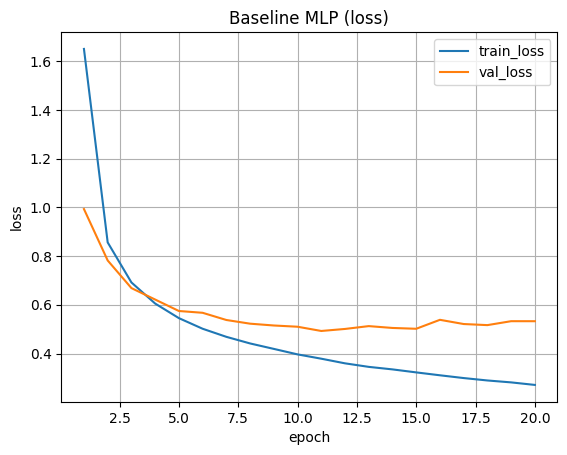

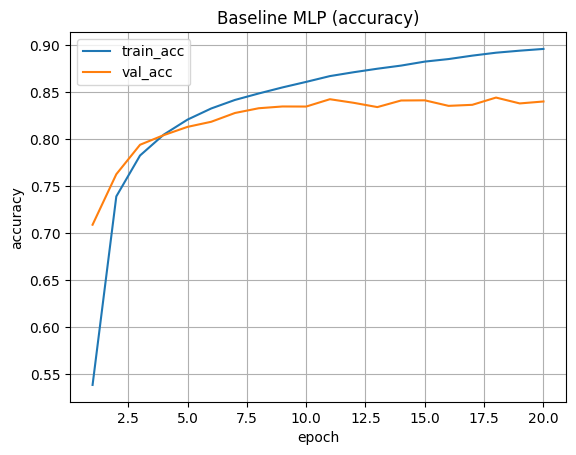

Default test: loss=0.5716, acc=0.8332


In [12]:
#   Модель 1
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(default_model.parameters(), lr=1e-3)

history_default = fit(
    default_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_default, title="Baseline MLP")
test_loss, test_acc = evaluate(default_model, test_loader, criterion, device)
print(f"Default test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=2.1133, acc=0.4002 | val loss=1.0532, acc=0.6846
epoch 02/20 | train loss=1.2405, acc=0.6239 | val loss=0.8211, acc=0.7477
epoch 03/20 | train loss=1.0463, acc=0.6782 | val loss=0.7148, acc=0.7744
epoch 04/20 | train loss=0.9504, acc=0.7051 | val loss=0.6584, acc=0.7875
epoch 05/20 | train loss=0.8821, acc=0.7236 | val loss=0.6242, acc=0.7977
epoch 06/20 | train loss=0.8418, acc=0.7347 | val loss=0.5928, acc=0.8066
epoch 07/20 | train loss=0.8020, acc=0.7450 | val loss=0.5745, acc=0.8125
epoch 08/20 | train loss=0.7781, acc=0.7532 | val loss=0.5673, acc=0.8152
epoch 09/20 | train loss=0.7528, acc=0.7611 | val loss=0.5493, acc=0.8178
epoch 10/20 | train loss=0.7304, acc=0.7644 | val loss=0.5410, acc=0.8215
epoch 11/20 | train loss=0.7187, acc=0.7697 | val loss=0.5339, acc=0.8237
epoch 12/20 | train loss=0.6987, acc=0.7747 | val loss=0.5205, acc=0.8283
epoch 13/20 | train loss=0.6860, acc=0.7772 | val loss=0.5151, acc=0.8267
epoch 14/20 | train loss=0.6806, acc=0

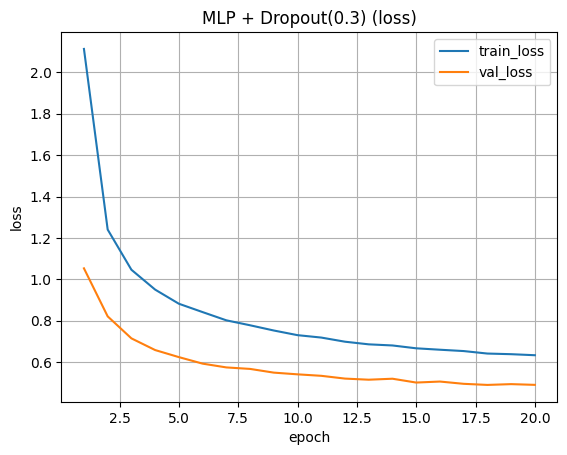

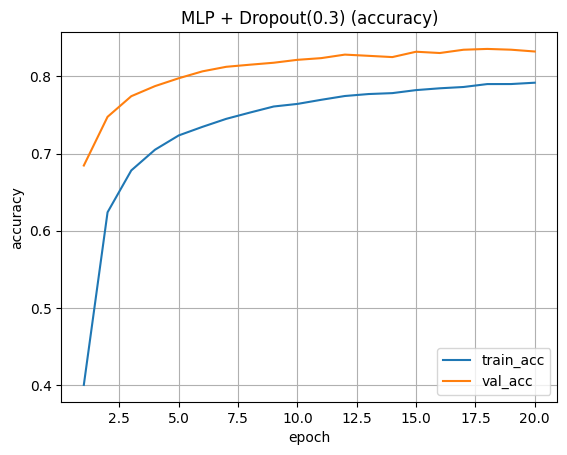

Dropout test: loss=0.5039, acc=0.8304


In [13]:
#   Модель 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.3170, acc=0.6953 | val loss=0.6590, acc=0.8008
epoch 02/20 | train loss=0.5607, acc=0.8207 | val loss=0.5311, acc=0.8311
epoch 03/20 | train loss=0.4549, acc=0.8478 | val loss=0.5020, acc=0.8352
epoch 04/20 | train loss=0.4021, acc=0.8596 | val loss=0.4815, acc=0.8415
epoch 05/20 | train loss=0.3651, acc=0.8692 | val loss=0.4725, acc=0.8422
epoch 06/20 | train loss=0.3366, acc=0.8776 | val loss=0.4587, acc=0.8484
epoch 07/20 | train loss=0.3142, acc=0.8831 | val loss=0.4561, acc=0.8470
epoch 08/20 | train loss=0.2952, acc=0.8898 | val loss=0.4595, acc=0.8502
epoch 09/20 | train loss=0.2777, acc=0.8956 | val loss=0.4635, acc=0.8487
epoch 10/20 | train loss=0.2654, acc=0.8969 | val loss=0.4773, acc=0.8437
epoch 11/20 | train loss=0.2510, acc=0.9029 | val loss=0.4848, acc=0.8455
epoch 12/20 | train loss=0.2394, acc=0.9061 | val loss=0.4806, acc=0.8477
epoch 13/20 | train loss=0.2289, acc=0.9104 | val loss=0.4953, acc=0.8488
epoch 14/20 | train loss=0.2187, acc=0

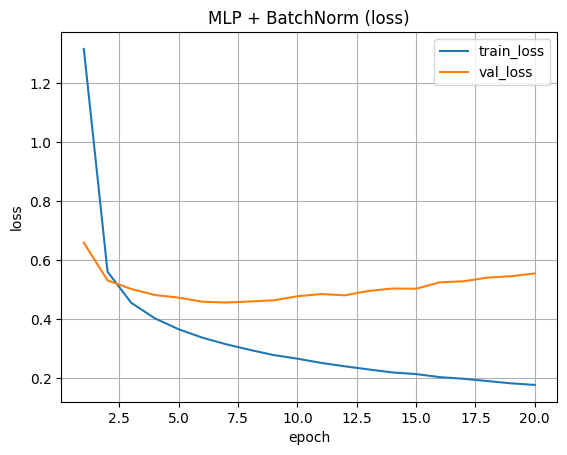

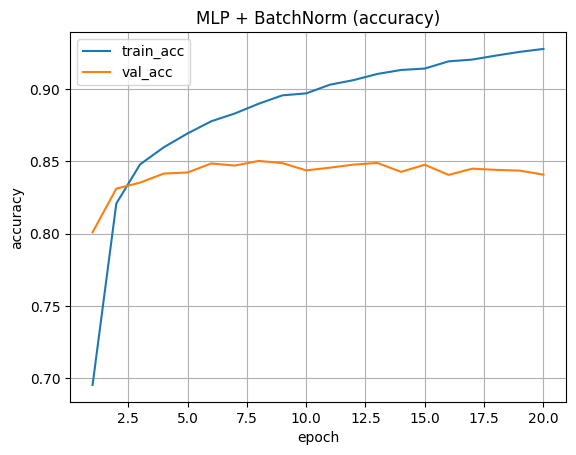

BatchNorm test: loss=0.5657, acc=0.8397


In [14]:
#   Модель 3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batchnorm_model.parameters(), lr=1e-3)

history_bn = fit(
    batchnorm_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(batchnorm_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [15]:
best_val_acc_dp = max(history_default['val_acc'])
best_val_acc_bn = max(history_bn['val_acc'])

if best_val_acc_dp > best_val_acc_bn:
    winner_val_acc = best_val_acc_dp
    print("Dropout Модель показала лучшие результаты")  
else:
    winner_val_acc = best_val_acc_bn
    print("BatchNorm Модель показала лучшие результаты")
print("Лучшая точность валидации:", winner_val_acc)

BatchNorm Модель показала лучшие результаты
Лучшая точность валидации: 0.8502018960674157


epoch 01/50 | train loss=1.3175, acc=0.6949 | val loss=0.6664, acc=0.7974
epoch 02/50 | train loss=0.5632, acc=0.8199 | val loss=0.5433, acc=0.8250
epoch 03/50 | train loss=0.4568, acc=0.8456 | val loss=0.4938, acc=0.8343
epoch 04/50 | train loss=0.4019, acc=0.8609 | val loss=0.4703, acc=0.8444
epoch 05/50 | train loss=0.3659, acc=0.8697 | val loss=0.4740, acc=0.8436
epoch 06/50 | train loss=0.3392, acc=0.8766 | val loss=0.4624, acc=0.8476
epoch 07/50 | train loss=0.3134, acc=0.8846 | val loss=0.4693, acc=0.8477
epoch 08/50 | train loss=0.2940, acc=0.8905 | val loss=0.4545, acc=0.8495
epoch 09/50 | train loss=0.2772, acc=0.8950 | val loss=0.4712, acc=0.8421
epoch 10/50 | train loss=0.2648, acc=0.8995 | val loss=0.4710, acc=0.8476
epoch 11/50 | train loss=0.2508, acc=0.9036 | val loss=0.4789, acc=0.8465
epoch 12/50 | train loss=0.2383, acc=0.9080 | val loss=0.4937, acc=0.8409
epoch 13/50 | train loss=0.2271, acc=0.9112 | val loss=0.5124, acc=0.8406
EarlyStopping: остановка на эпохе 13. 

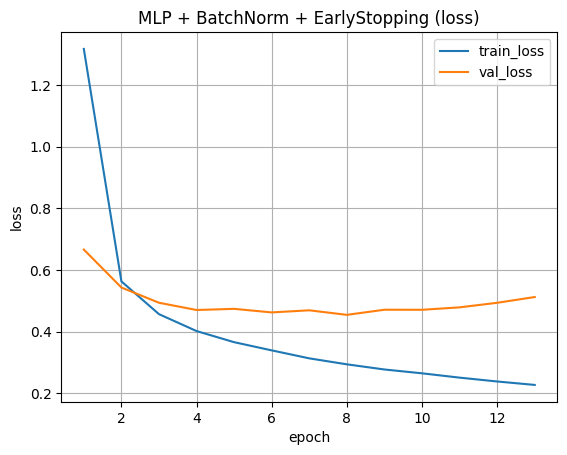

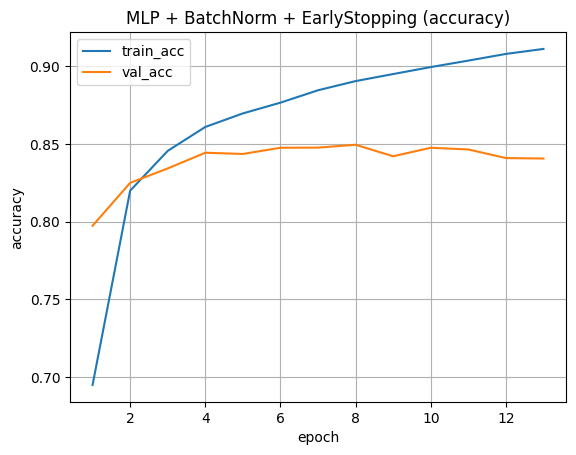

Combo test: loss=0.4761, acc=0.8458


In [16]:
#Так как BatchNorm модель оказалась лучше, обучим ее используя EarlyStopping

combo_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=5, min_delta=0.0005)


history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50, 
    early_stopping=es,
    verbose=True
)


plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [17]:
#   Сравнение моделей на test - dataset

results = {
    "default model": evaluate(default_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout model": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm model": evaluate(batchnorm_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo model": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

default model: test_acc=0.8332
dropout model: test_acc=0.8304
batchnorm model: test_acc=0.8397
combo model: test_acc=0.8458


In [18]:
# Общие параметры для экспериментов O1-O3
import pandas as pd

EPOCHS = 6

def make_model():
    return MLP(input_dim=28*28, num_classes=47).to(device)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS, device = device):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True, device=device)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }


Эксперимент O1: Adam lr=0.1
epoch 01/6 | train loss=4.3253, acc=0.0429 | val loss=3.6753, acc=0.0272
epoch 02/6 | train loss=3.6170, acc=0.0398 | val loss=3.5620, acc=0.0441
epoch 03/6 | train loss=3.5597, acc=0.0403 | val loss=3.5503, acc=0.0424
epoch 04/6 | train loss=3.5585, acc=0.0399 | val loss=3.5580, acc=0.0403
epoch 05/6 | train loss=3.5826, acc=0.0393 | val loss=3.5940, acc=0.0423
epoch 06/6 | train loss=3.5956, acc=0.0391 | val loss=3.5954, acc=0.0406


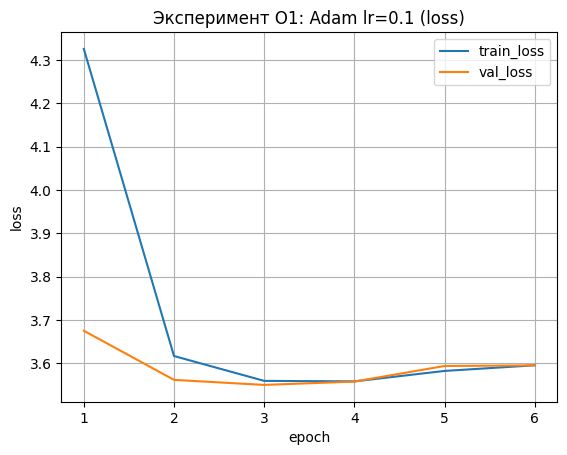

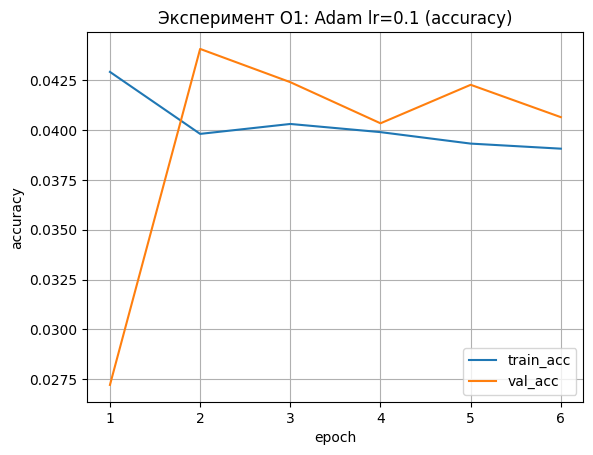

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,Эксперимент O1,adam,0.1,0.0,6,0.044066,3.550343


In [19]:
#Эксперимент O1
name = "Эксперимент O1"
lr = 1e-1
results_lr_o1 = []
print("\n" + "="*80)
print(f"{name}: Adam lr={lr}")
res_o1 = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr, device=device)
results_lr_o1.append(res_o1)
plot_history(res_o1["history"], title=f"{name}: Adam lr={lr}")

rows_o1 = []
for r in results_lr_o1:
    rows_o1.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })


df_lr_o1 = pd.DataFrame(rows_o1).sort_values(by="best_val_acc", ascending=False)
display(df_lr_o1)


Эксперимент O2: Adam lr=1e-05
epoch 01/6 | train loss=3.8243, acc=0.0510 | val loss=3.7825, acc=0.0933
epoch 02/6 | train loss=3.7069, acc=0.1515 | val loss=3.6128, acc=0.2047
epoch 03/6 | train loss=3.4855, acc=0.2640 | val loss=3.3493, acc=0.3254
epoch 04/6 | train loss=3.1965, acc=0.3574 | val loss=3.0451, acc=0.3930
epoch 05/6 | train loss=2.8901, acc=0.4114 | val loss=2.7449, acc=0.4328
epoch 06/6 | train loss=2.6070, acc=0.4480 | val loss=2.4832, acc=0.4635


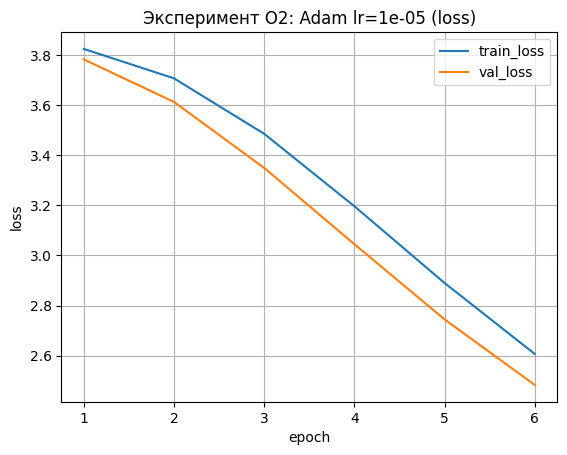

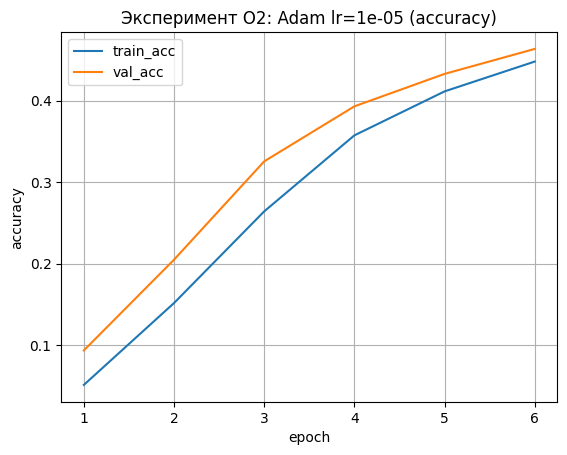

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,Эксперимент O2,adam,0.00001,0.0,6,0.463527,2.483235


In [20]:
#Эксперимент O2
name = "Эксперимент O2"
lr = 1e-5
results_lr_o2 = []
print("\n" + "="*80)
print(f"{name}: Adam lr={lr}")
res_o2 = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr, device=device)
results_lr_o2.append(res_o2)
plot_history(res_o2["history"], title=f"{name}: Adam lr={lr}")

rows_o2 = []
for r in results_lr_o2:
    rows_o2.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr_o2 = pd.DataFrame(rows_o2).sort_values(by="best_val_acc", ascending=False)
display(df_lr_o2)


Experiment OPT_SGD: SGD lr=0.01 momentum=0.9 weight_decay=1e-4
epoch 01/15 | train loss=2.8393, acc=0.2928 | val loss=1.6096, acc=0.5571
epoch 02/15 | train loss=1.4000, acc=0.6053 | val loss=1.2632, acc=0.6420
epoch 03/15 | train loss=1.1539, acc=0.6701 | val loss=1.0707, acc=0.6934
epoch 04/15 | train loss=0.9878, acc=0.7117 | val loss=0.9317, acc=0.7282
epoch 05/15 | train loss=0.8651, acc=0.7440 | val loss=0.8325, acc=0.7547
epoch 06/15 | train loss=0.7781, acc=0.7656 | val loss=0.7661, acc=0.7714
epoch 07/15 | train loss=0.7155, acc=0.7828 | val loss=0.7198, acc=0.7809
epoch 08/15 | train loss=0.6663, acc=0.7942 | val loss=0.6843, acc=0.7923
epoch 09/15 | train loss=0.6273, acc=0.8048 | val loss=0.6531, acc=0.7987
epoch 10/15 | train loss=0.5962, acc=0.8118 | val loss=0.6190, acc=0.8073
epoch 11/15 | train loss=0.5687, acc=0.8204 | val loss=0.6054, acc=0.8135
epoch 12/15 | train loss=0.5461, acc=0.8256 | val loss=0.5850, acc=0.8204
epoch 13/15 | train loss=0.5242, acc=0.8302 | va

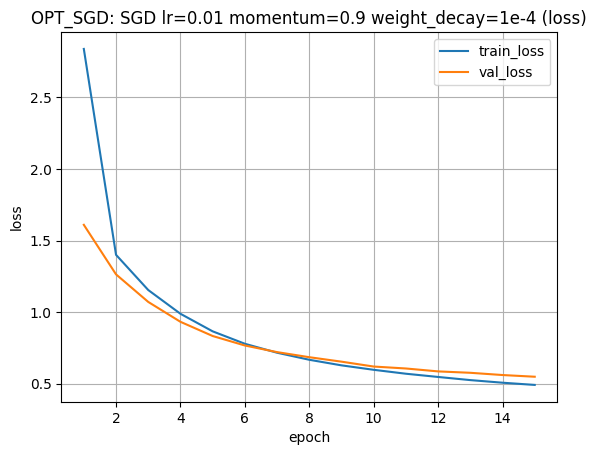

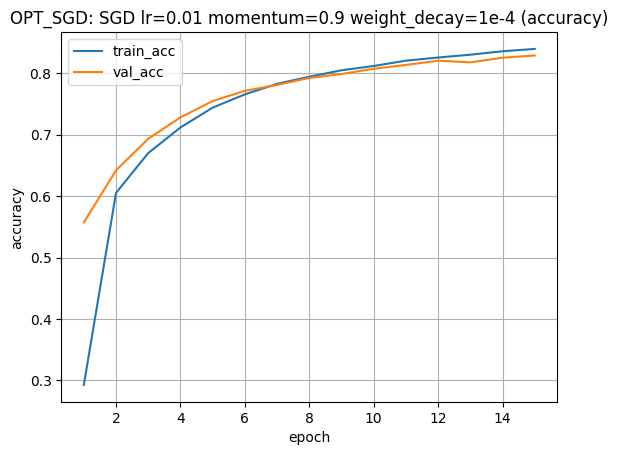

,exp_id,optimizer,lr,momentum,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,OPT_SGD,sgd,0.01,0.9,0.0001,15,0.828871,0.547755


In [21]:
#Эксперимент O3

results_opt = []

print("\n" + "="*80)
print("Experiment OPT_SGD: SGD lr=0.01 momentum=0.9 weight_decay=1e-4")
res_sgd = run_experiment(exp_id="OPT_SGD", weight_decay=1e-4, optimizer_kind="sgd", lr=0.01, momentum=0.9, epochs=15)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="OPT_SGD: SGD lr=0.01 momentum=0.9 weight_decay=1e-4")

rows_o3 = []
for r in results_opt:
    rows_o3.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_o3 = pd.DataFrame(rows_o3).sort_values(by="best_val_acc", ascending=False)
display(df_o3)

In [23]:
#Создание артефактов

import csv
import json

#   СОЗДАЕМ runs.csv
history_o1 = res_o1["history"]
history_o2 = res_o2["history"]
history_o3 = res_sgd["history"]
experiments = [
    # E1: Baseline (Default model)
    {
        'experiment_id': 'E1',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=False/EarlyStopping=False',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_default['val_acc']),
        'best_val_accuracy': round(max(history_default['val_acc']), 4),
        'best_val_loss': round(min(history_default['val_loss']), 4),
    },
    # E2: Dropout
    {
        'experiment_id': 'E2',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.3/batchnorm=False/EarlyStopping=False',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_dropout['val_acc']),
        'best_val_accuracy': round(max(history_dropout['val_acc']), 4),
        'best_val_loss': round(min(history_dropout['val_loss']), 4),
    },
    # E3: BatchNorm
    {
        'experiment_id': 'E3',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=True/EarlyStopping=False',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_bn['val_acc']),
        'best_val_accuracy': round(max(history_bn['val_acc']), 4),
        'best_val_loss': round(min(history_bn['val_loss']), 4),
    },
    # E4: Best model (BatchNorm + EarlyStopping)
    {
        'experiment_id': 'E4',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=True/EarlyStopping=True',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_combo['val_acc']),
        'best_val_accuracy': round(max(history_combo['val_acc']), 4),
        'best_val_loss': round(min(history_combo['val_loss']), 4),
    },
    # O1: LR слишком большой
    {
        'experiment_id': 'O1',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=False/EarlyStopping=False',
        'optimizer': 'Adam',
        'lr': 1e-1,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_o1['val_acc']),
        'best_val_accuracy': round(max(history_o1['val_acc']), 4),
        'best_val_loss': round(min(history_o1['val_loss']), 4),
    },
    # O2: LR слишком маленький
    {
        'experiment_id': 'O2',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=False/EarlyStopping=False',
        'optimizer': 'Adam',
        'lr': 1e-5,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history_o2['val_acc']),
        'best_val_accuracy': round(max(history_o2['val_acc']), 4),
        'best_val_loss': round(min(history_o2['val_loss']), 4),
    },
    # O3: LR оптимальный
    {
        'experiment_id': 'O3',
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': '256-128-64/ReLU/dropout=0.0/batchnorm=False/EarlyStopping=False',
        'optimizer': 'SGD',
        'lr': 0.01,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'epochs_trained': len(history_o3['val_acc']),
        'best_val_accuracy': round(max(history_o3['val_acc']), 4),
        'best_val_loss': round(min(history_o3['val_loss']), 4),
    },
]

fieldnames = [
    'experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer',
    'lr', 'momentum', 'weight_decay', 'epochs_trained',
    'best_val_accuracy', 'best_val_loss'
]

with open('artifacts/runs.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(experiments)

# Сохраняем веса лучшей модели

es.restore_best(combo_model)

torch.save(combo_model.state_dict(), 'artifacts/best_model.pt')

#   BEST CONFIG
best_config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_architecture': {
        'input_dim': 28 * 28,
        'hidden_dims': [256, 128, 64],
        'num_classes': 47,
        'activation': 'ReLU',
        'dropout_p': 0.0,
        'use_batchnorm': True
    },
    'training_hyperparameters': {
        'optimizer': 'Adam',
        'lr': 0.001,
        'weight_decay': 0,
        'batch_size': BATCH_SIZE,
        'epochs': 50,
        'early_stopping': {
            'patience': 5,
            'min_delta': 0.0005
        }
    },
    'results': {
        'best_val_accuracy': float(round(max(history_combo['val_acc']), 4)),
        'best_val_loss': float(round(min(history_combo['val_loss']), 4)),
        'epochs_trained': len(history_combo['val_acc'])
    },
}

with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

# ГРАФИКИ E4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Loss curve
axes[0].plot(history_combo['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history_combo['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('E4: Train/Val Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Accuracy curve
axes[1].plot(history_combo['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[1].plot(history_combo['val_acc'], label='Val Acc', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('E4: Train/Val Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.close()

#ГРАФИКИ O1 & O2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# O1: LR слишком большой
axes[0].plot(history_o1['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history_o1['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('O1: LR=0.1 (слишком большой)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# O2: LR слишком маленький
axes[1].plot(history_o2['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[1].plot(history_o2['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('O2: LR=1e-5 (слишком маленький)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.close()